In [2]:
import pandas as pd

titanic = pd.read_csv('titanic.csv')
titanic.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


### Matríz de características

In [ ]:
features = ['Pclass', 'Sex', 'SibSp', 'Parch', 'Fare','Embarked']
X_pre = titanic[features]
X = pd.get_dummies(X_pre, columns = ['Sex','Embarked'], drop_first=True)

x_final.head()

,Pclass,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,1,0,7.2500,True,False,True
1,1,1,0,71.2833,False,False,False
2,3,0,0,7.9250,False,False,True
3,1,1,0,53.1000,False,False,True
4,3,0,0,8.0500,True,False,True


### Vector de respuesta

In [15]:
y = titanic['Survived']

y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

## Creación del modelo

In [17]:
from sklearn.tree import DecisionTreeClassifier
modelo = DecisionTreeClassifier(
max_depth=3, random_state=42
)

### Ajuste del modelo

In [18]:
modelo.fit(X, y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

### Valor de predicción

In [19]:
y_pred = modelo.predict(X)

### Visualización del árbol

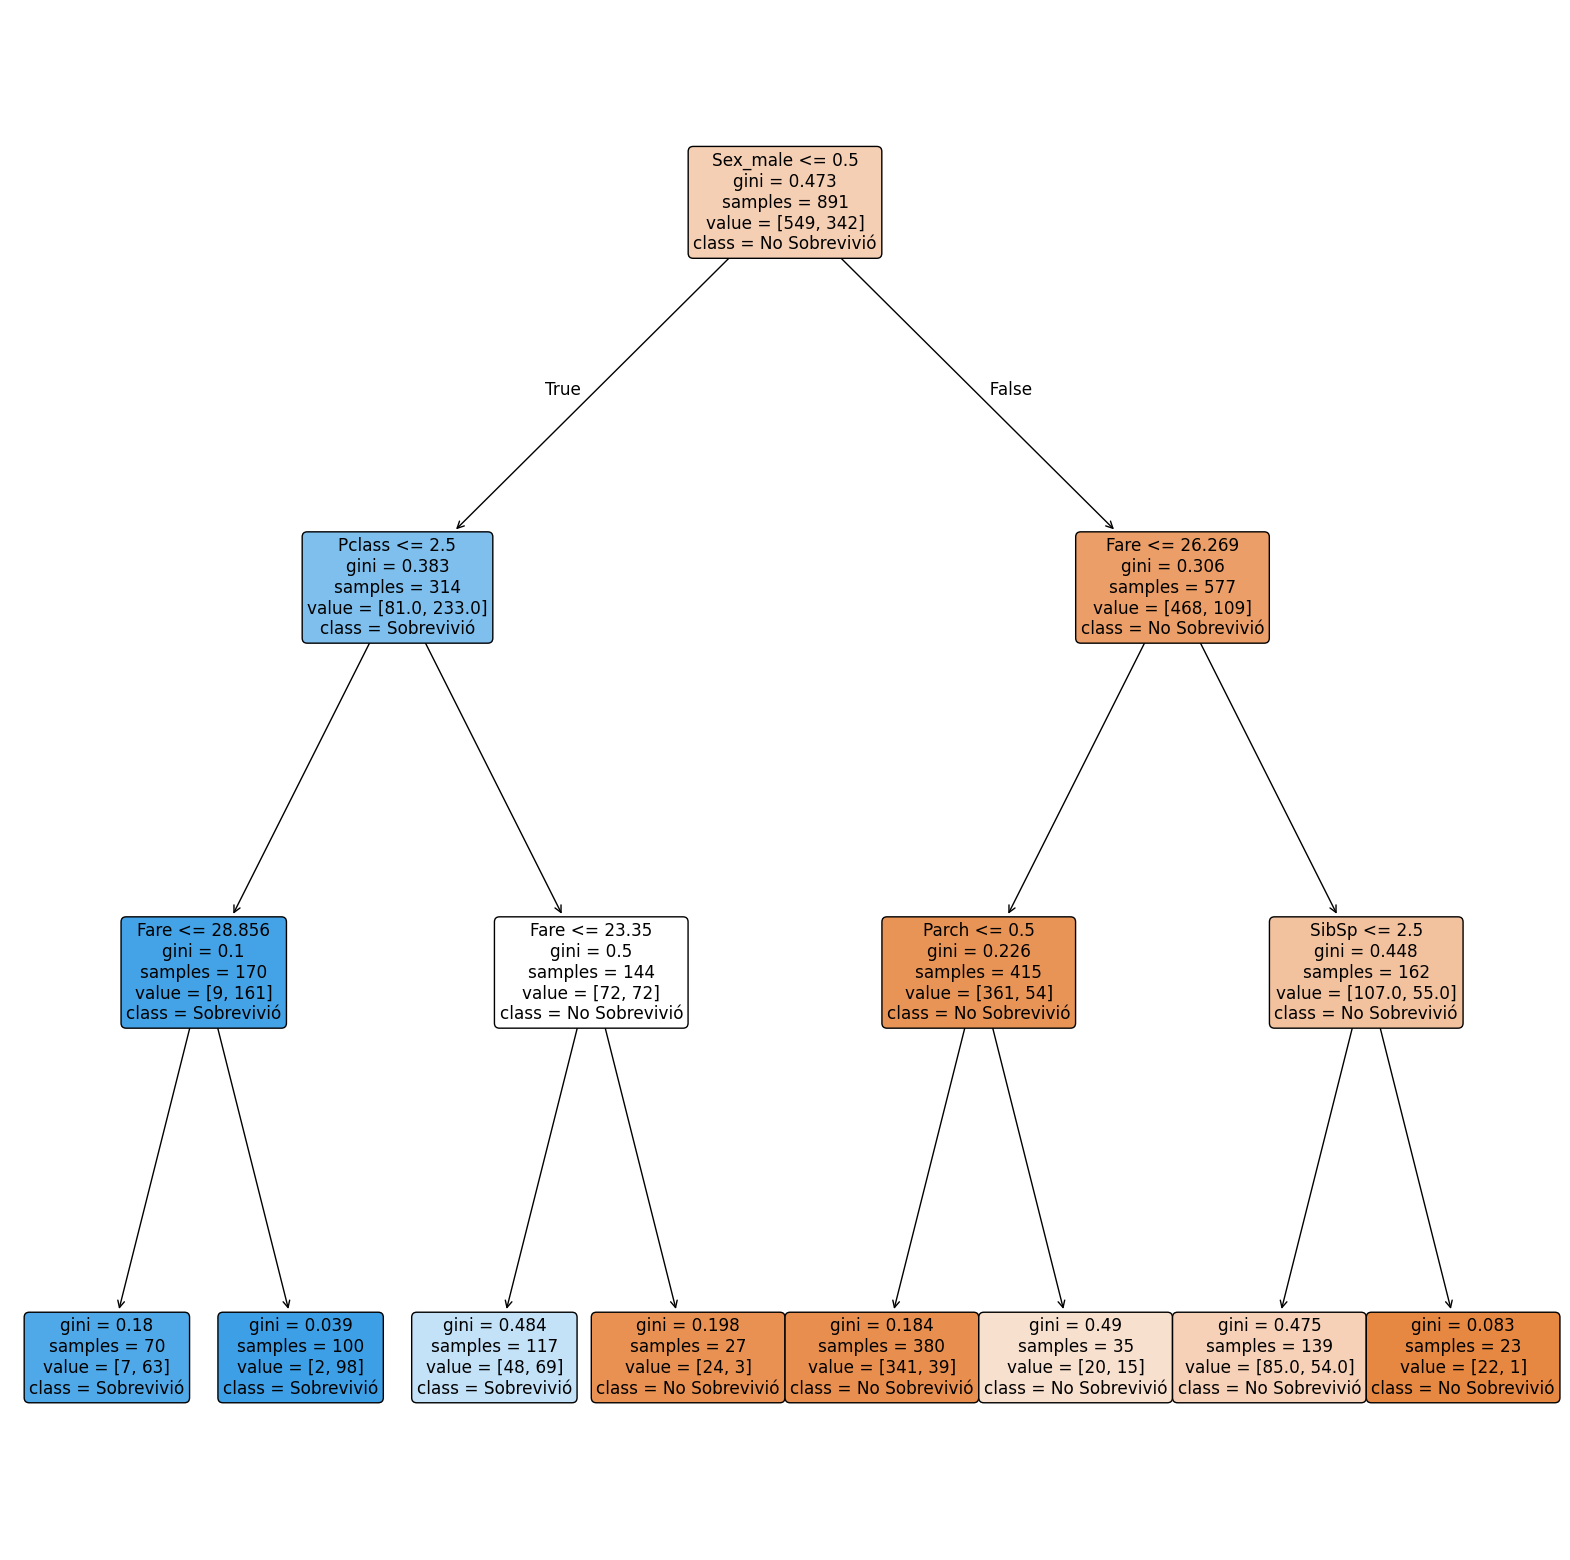

In [21]:
from sklearn.tree import plot_tree
from matplotlib import pyplot
figure, axis = pyplot.subplots(figsize=(20, 20))
plot_tree(modelo, ax=axis, feature_names=X.columns, filled=True, class_names=['No Sobrevivió', 'Sobrevivió'], rounded=True)
pyplot.show()

### Matríz de confusión

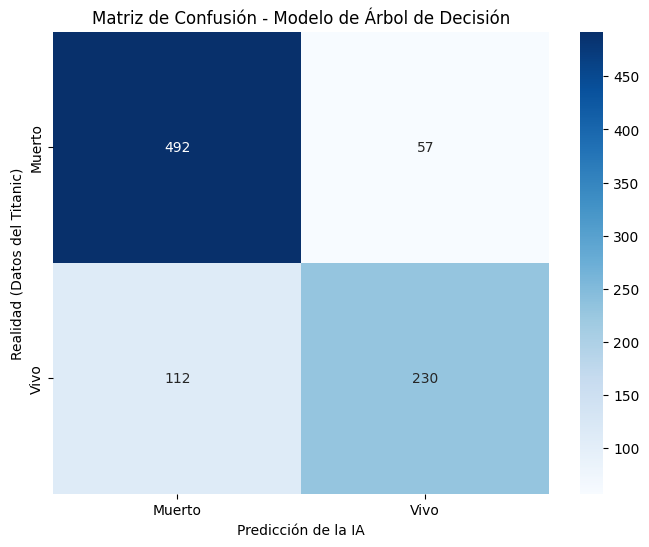

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

matriz = confusion_matrix(y, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Muerto', 'Vivo'], 
            yticklabels=['Muerto', 'Vivo'])

plt.title('Matriz de Confusión - Modelo de Árbol de Decisión')
plt.xlabel('Predicción de la IA')
plt.ylabel('Realidad (Datos del Titanic)')
plt.show()

### Matríz X'

In [37]:
X.head(10)

,Pclass,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,1,0,7.2500,True,False,True
1,1,1,0,71.2833,False,False,False
2,3,0,0,7.9250,False,False,True
3,1,1,0,53.1000,False,False,True
4,3,0,0,8.0500,True,False,True
5,3,0,0,8.4583,True,True,False
6,1,0,0,51.8625,True,False,True
7,3,3,1,21.0750,True,False,True
8,3,0,2,11.1333,False,False,True
9,2,1,0,30.0708,False,False,False


In [38]:
observaciones = [
    [1, 0, 0, 0, 7.25, 0, 0],
    [3, 1, 0, 0, 7.925, 0, 1],
    [2, 0, 1, 0, 7.925, 0, 0],
]

observaciones_df = pd.DataFrame(observaciones, columns=X.columns)
observaciones_df.head()

,Pclass,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,1,0,0,0,7.250,0,0
1,3,1,0,0,7.925,0,1
2,2,0,1,0,7.925,0,0


### Vector de respuesta sobre la matriz con observaciones

In [39]:
y_ob_pred = modelo.predict(observaciones_df)
print(y_ob_pred)

[0 0 0]


### Matríz de confusión

In [45]:
from sklearn.metrics import confusion_matrix
tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()
# La precision para decir que tan verdadera es la prediccionQ
p = tp / (tp + fp)
# La sensibilidad para determinar que tanta verdad se captura
s = tp / (tp + fn)
# El factor F1 para determinar el balance
# entre precision y sensibilidad
5
f1 = 2 * (p * s) / (p + s)
# La especificidad para determinar que tanta falsedad se captura
e = tn / (tn + fp)
# La exactitud para determinar que tanto
# se captura en la diagonal
a = (tp + tn) / (tp + tn + fn + fp)
pd.DataFrame({
"accuracy": [a],
"Precision": [p],
"Sensivity": [s],
"Specificity": [e],
"f1-score": [f1],
}).T

,0
accuracy,0.810325
Precision,0.801394
Sensivity,0.672515
Specificity,0.896175
f1-score,0.731320


## Modelo por curva logística

In [46]:
from sklearn.linear_model import LogisticRegression
modelo_cl = LogisticRegression(max_iter=1000, random_state=42)

In [47]:
modelo_cl.fit(X, y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [48]:
y_pred_cl = modelo_cl.predict(X)

<Axes: >

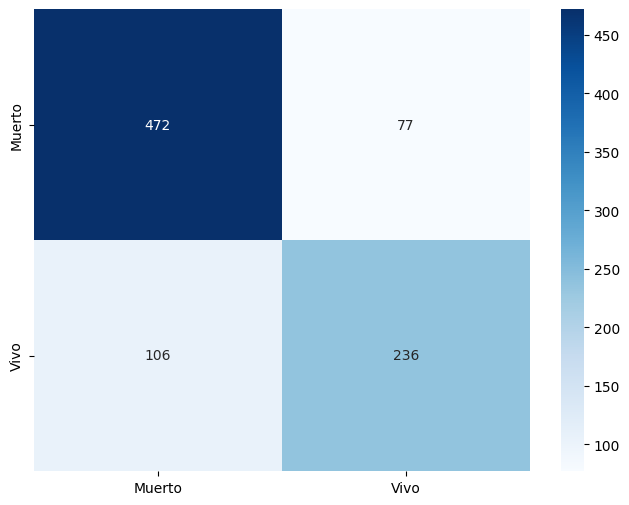

In [49]:
cl_matrix = confusion_matrix(y, y_pred_cl)
plt.figure(figsize=(8, 6))
sns.heatmap(cl_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Muerto', 'Vivo'], 
            yticklabels=['Muerto', 'Vivo'])

In [50]:
tn, fp, fn, tp = confusion_matrix(y, y_pred_cl).ravel()
# La precision para decir que tan verdadera es la prediccionQ
p = tp / (tp + fp)
# La sensibilidad para determinar que tanta verdad se captura
s = tp / (tp + fn)
# El factor F1 para determinar el balance
# entre precision y sensibilidad
5
f1 = 2 * (p * s) / (p + s)
# La especificidad para determinar que tanta falsedad se captura
e = tn / (tn + fp)
# La exactitud para determinar que tanto
# se captura en la diagonal
a = (tp + tn) / (tp + tn + fn + fp)
pd.DataFrame({
"accuracy": [a],
"Precision": [p],
"Sensivity": [s],
"Specificity": [e],
"f1-score": [f1],
}).T

,0
accuracy,0.794613
Precision,0.753994
Sensivity,0.690058
Specificity,0.859745
f1-score,0.720611


### Predicción sobre X'

In [51]:
x_prime_cl = modelo_cl.predict(observaciones_df)
print(x_prime_cl)

[0 0 0]


### PCA con ayuda de la IA

In [53]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import numpy as np

# --- PASO A: Normalización y PCA ---
# Escalamos X para que todas las variables tengan el mismo peso
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reducimos a 1 solo componente (c)
pca = PCA(n_components=1)
c = pca.fit_transform(X_scaled)

# --- PASO B: Entrenamiento de Modelos ---
# 1. Árbol de Decisión
modelo_arbol = DecisionTreeClassifier(max_depth=3, random_state=42)
modelo_arbol.fit(X, y) # Entrenamos con X original
y_p_arbol = modelo_arbol.predict(X)

# 2. Regresión Logística (Curva Logística)
modelo_log = LogisticRegression(max_iter=1000,random_state=42)
modelo_log.fit(X, y)
y_p_log = modelo_log.predict(X)

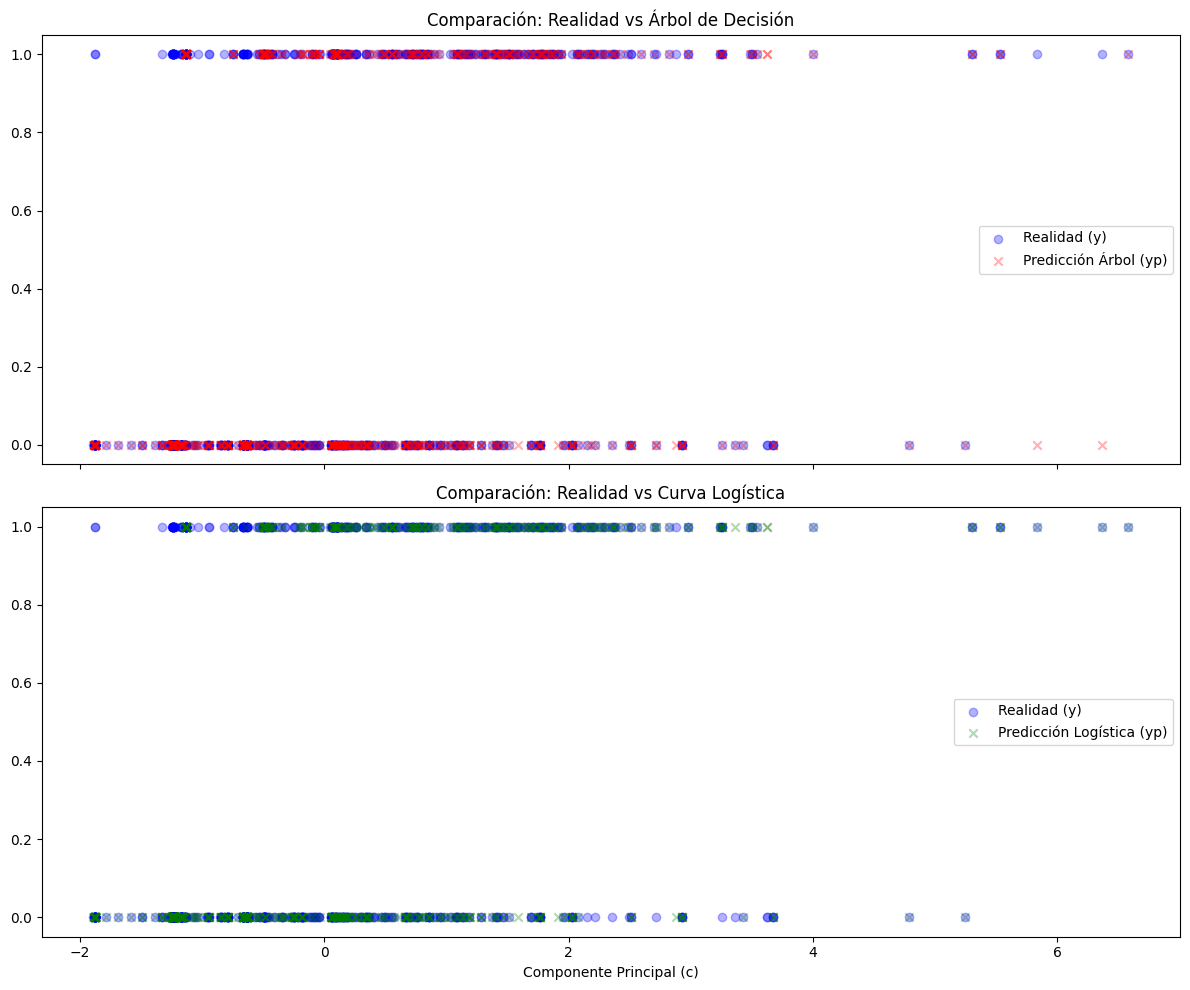

In [54]:
# Creamos una figura con dos subgráficas
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Gráfica 1: Árbol de Decisión
ax1.scatter(c, y, color='blue', alpha=0.3, label='Realidad (y)', marker='o')
ax1.scatter(c, y_p_arbol, color='red', alpha=0.3, label='Predicción Árbol (yp)', marker='x')
ax1.set_title('Comparación: Realidad vs Árbol de Decisión')
ax1.legend()

# Gráfica 2: Curva Logística
ax2.scatter(c, y, color='blue', alpha=0.3, label='Realidad (y)', marker='o')
ax2.scatter(c, y_p_log, color='green', alpha=0.3, label='Predicción Logística (yp)', marker='x')
ax2.set_title('Comparación: Realidad vs Curva Logística')
ax2.set_xlabel('Componente Principal (c)')
ax2.legend()

plt.tight_layout()
plt.show()